Enter full path to the image file: /content/lena.png


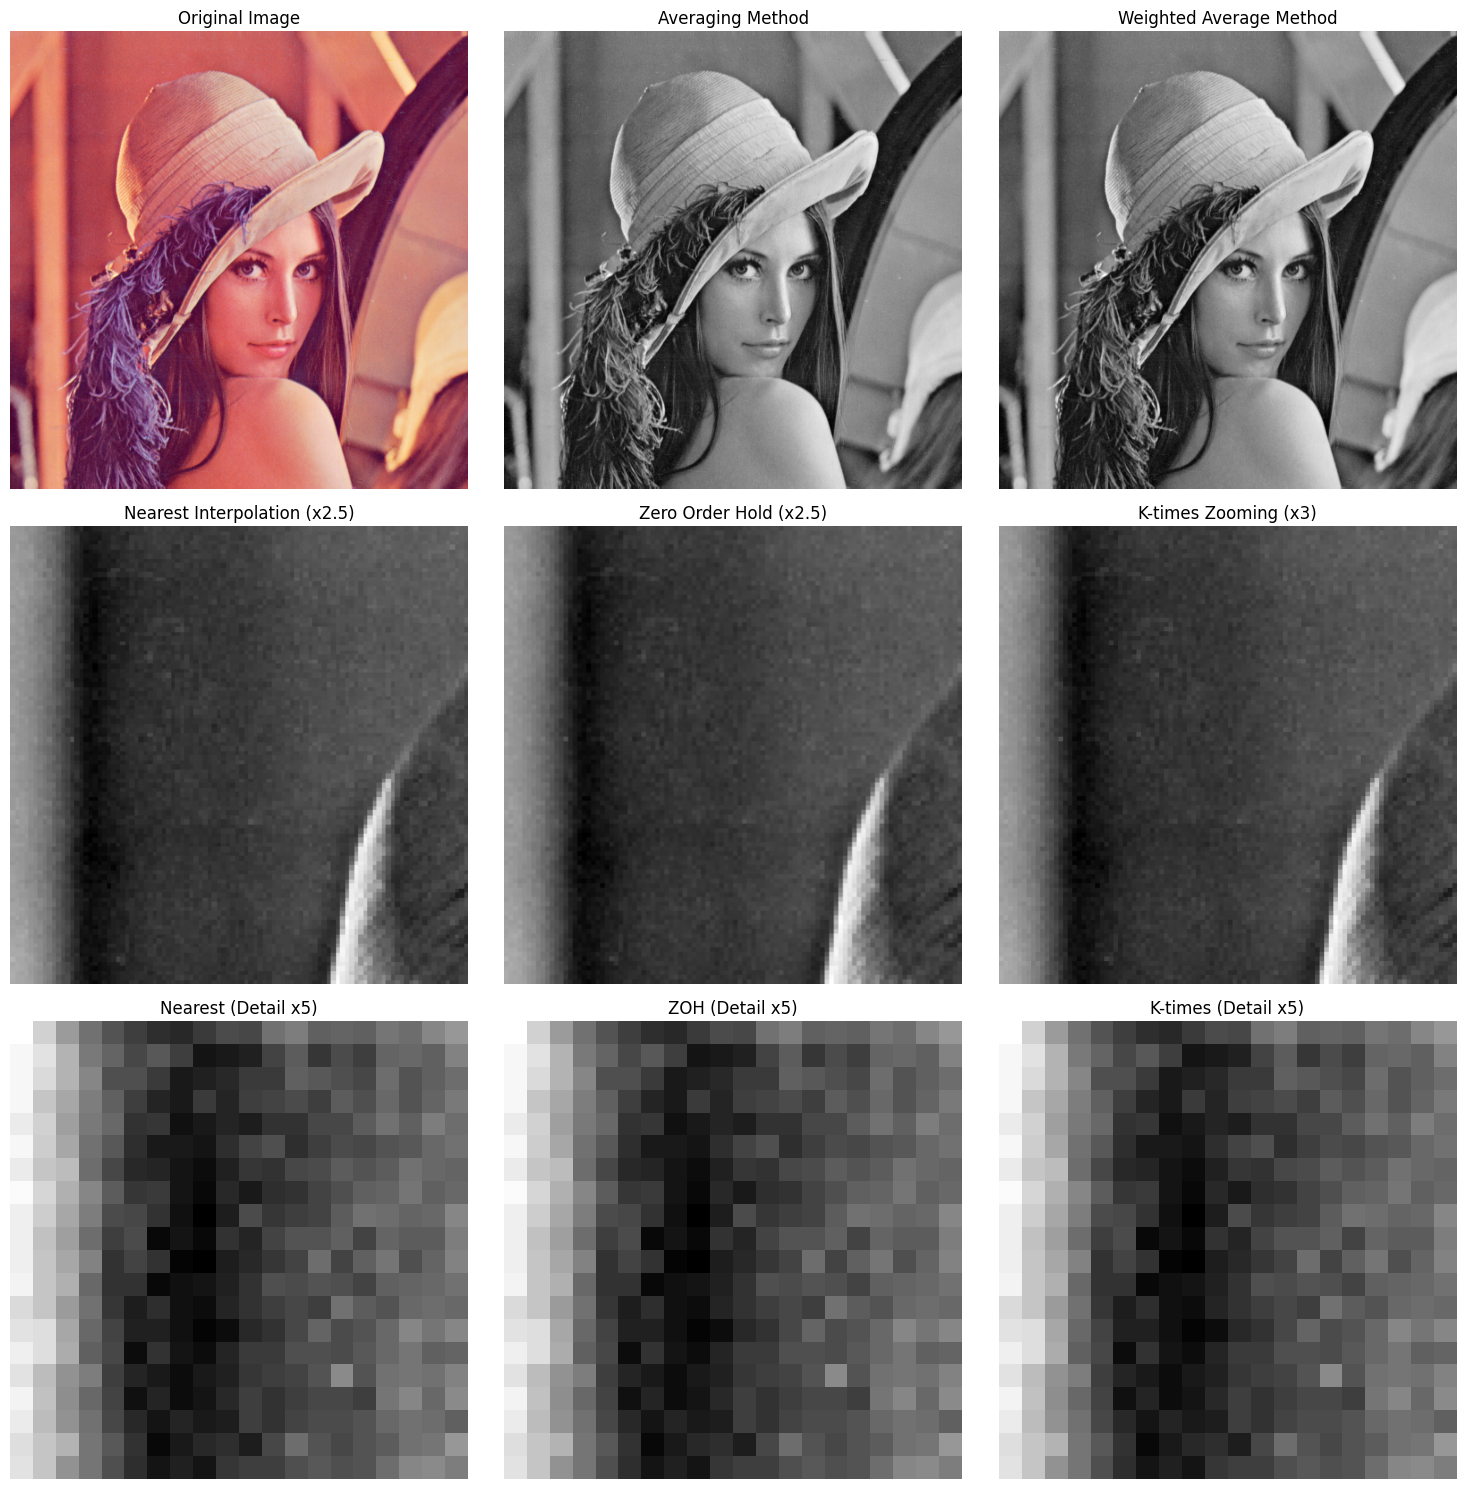

Original image shape: (512, 512, 3)
Grayscale (Averaging) - Min: 35, Max: 240
Grayscale (Weighted) - Min: 24, Max: 245
Nearest interpolation output shape: (250, 250)
Zero order hold output shape: (200, 200)
K-times zooming output shape: (300, 300)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def load_image():
    file_path = input("Enter full path to the image file: ").strip()
    try:
        img = Image.open(file_path)
        return np.array(img)
    except:
        print("Failed to load image. Check the path.")
        return None

def averaging_method(img):
    if len(img.shape) == 3:
        gray = np.mean(img, axis=2)
    else:
        gray = img
    return gray.astype(np.uint8)

def weighted_average_method(img):
    if len(img.shape) == 3:
        gray = 0.299 * img[:,:,0] + 0.587 * img[:,:,1] + 0.114 * img[:,:,2]
    else:
        gray = img
    return gray.astype(np.uint8)

def nearest_interpolation(img, zoom_factor):
    h, w = img.shape[:2]
    new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)
    if len(img.shape) == 2:
        zoomed = np.zeros((new_h, new_w), dtype=img.dtype)
        for i in range(new_h):
            for j in range(new_w):
                zoomed[i, j] = img[int(i/zoom_factor), int(j/zoom_factor)]
    else:
        c = img.shape[2]
        zoomed = np.zeros((new_h, new_w, c), dtype=img.dtype)
        for i in range(new_h):
            for j in range(new_w):
                zoomed[i, j] = img[int(i/zoom_factor), int(j/zoom_factor)]
    return zoomed

def zero_order_hold(img, zoom_factor):
    h, w = img.shape[:2]
    new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)
    zoomed = np.repeat(np.repeat(img, int(zoom_factor), axis=0), int(zoom_factor), axis=1)
    return zoomed[:new_h, :new_w]

def k_times_zooming(img, k):
    if len(img.shape) == 2:
        h, w = img.shape
        zoomed = np.zeros((h*k, w*k), dtype=img.dtype)
        for i in range(h):
            for j in range(w):
                zoomed[i*k:(i+1)*k, j*k:(j+1)*k] = img[i, j]
    else:
        h, w, c = img.shape
        zoomed = np.zeros((h*k, w*k, c), dtype=img.dtype)
        for i in range(h):
            for j in range(w):
                zoomed[i*k:(i+1)*k, j*k:(j+1)*k] = img[i, j]
    return zoomed

# ------------------ Main ------------------
original_img = load_image()

if original_img is not None:
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))

    axes[0, 0].imshow(original_img)
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')

    gray_avg = averaging_method(original_img)
    axes[0, 1].imshow(gray_avg, cmap='gray')
    axes[0, 1].set_title('Averaging Method')
    axes[0, 1].axis('off')

    gray_weighted = weighted_average_method(original_img)
    axes[0, 2].imshow(gray_weighted, cmap='gray')
    axes[0, 2].set_title('Weighted Average Method')
    axes[0, 2].axis('off')

    zoom_factor = 2.5
    k_factor = 3
    test_img = gray_weighted[50:150, 50:150] if gray_weighted.shape[0] > 150 else gray_weighted

    nearest_zoomed = nearest_interpolation(test_img, zoom_factor)
    axes[1, 0].imshow(nearest_zoomed, cmap='gray')
    axes[1, 0].set_title(f'Nearest Interpolation (x{zoom_factor})')
    axes[1, 0].axis('off')

    zoh_zoomed = zero_order_hold(test_img, zoom_factor)
    axes[1, 1].imshow(zoh_zoomed, cmap='gray')
    axes[1, 1].set_title(f'Zero Order Hold (x{zoom_factor})')
    axes[1, 1].axis('off')

    k_zoomed = k_times_zooming(test_img, k_factor)
    axes[1, 2].imshow(k_zoomed, cmap='gray')
    axes[1, 2].set_title(f'K-times Zooming (x{k_factor})')
    axes[1, 2].axis('off')

    small_section = test_img[10:30, 10:30] if test_img.shape[0] > 30 else test_img

    nearest_detail = nearest_interpolation(small_section, 5)
    axes[2, 0].imshow(nearest_detail, cmap='gray')
    axes[2, 0].set_title('Nearest (Detail x5)')
    axes[2, 0].axis('off')

    zoh_detail = zero_order_hold(small_section, 5)
    axes[2, 1].imshow(zoh_detail, cmap='gray')
    axes[2, 1].set_title('ZOH (Detail x5)')
    axes[2, 1].axis('off')

    k_detail = k_times_zooming(small_section, 5)
    axes[2, 2].imshow(k_detail, cmap='gray')
    axes[2, 2].set_title('K-times (Detail x5)')
    axes[2, 2].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"Original image shape: {original_img.shape}")
    print(f"Grayscale (Averaging) - Min: {gray_avg.min()}, Max: {gray_avg.max()}")
    print(f"Grayscale (Weighted) - Min: {gray_weighted.min()}, Max: {gray_weighted.max()}")
    print(f"Nearest interpolation output shape: {nearest_zoomed.shape}")
    print(f"Zero order hold output shape: {zoh_zoomed.shape}")
    print(f"K-times zooming output shape: {k_zoomed.shape}")
else:
    print("No image found or failed to load.")
